# RAFT (Recurrent All-Pairs Field Transforms) Optical Flow Setup

This notebook provides a complete setup for the official RAFT optical flow repository in Google Colab, from cloning the repository to running inference and preparing for training with Google Drive integration.

In [1]:
from google.colab import drive
drive.mount('/content/drive')


ModuleNotFoundError: No module named 'google'

## 1. GPU Verification

First, let's verify that a GPU is available and check its specifications using `nvidia-smi`.

In [ ]:
# Check GPU availability and details
!nvidia-smi

Sat Jul  4 06:16:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Clone RAFT GitHub Repository

Clone the official RAFT repository from GitHub. This will create a `RAFT` directory in the current working directory.

In [ ]:
import subprocess
import os

# Clone the RAFT repository
RAFT_REPO_URL = "https://github.com/princeton-vl/RAFT.git"
RAFT_DIR = "RAFT"

if not os.path.exists(RAFT_DIR):
    print(f"Cloning {RAFT_REPO_URL}...")
    subprocess.run(["git", "clone", RAFT_REPO_URL])
    print("RAFT repository cloned successfully.")
else:
    print(f"Directory '{RAFT_DIR}' already exists. Skipping cloning.")

Directory 'RAFT' already exists. Skipping cloning.


## 3. Change Directory to RAFT

Navigate into the cloned `RAFT` directory to perform subsequent operations like installing dependencies and running scripts.

In [ ]:
# Change current working directory to the RAFT directory
%cd RAFT

print(f"Current working directory: {os.getcwd()}")

/content/RAFT
Current working directory: /content/RAFT


## 4. Install Dependencies

Install all required Python packages listed in `requirements.txt`, along with other necessary packages for image processing, visualization, and deep learning (`opencv-python`, `imageio`, `tensorboard`, `tqdm`).

We explicitly install `torch` and `torchvision` again to ensure compatibility with the GPU environment in Colab, although `requirements.txt` might also list them. Installing `gdown` is necessary for downloading the pretrained model from Google Drive.

In [ ]:
# Install dependencies
print("Installing necessary packages...")

# The RAFT repository does not provide a requirements.txt, so we install common dependencies directly.
# Ensure torch and torchvision are installed for CUDA compatibility.
!pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu121
!pip install opencv-python scipy matplotlib imageio tensorboard tqdm gdown

print("All specified dependencies installed.")

Installing necessary packages...
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 25.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 108.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 89.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 62.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 110.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 22.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━

All specified dependencies installed.


## 5. Verify PyTorch GPU Detection

Confirm that PyTorch can detect and utilize the GPU for computations.

In [ ]:
import torch

# Verify PyTorch GPU detection
if torch.cuda.is_available():
    print(f"PyTorch detected GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("PyTorch did not detect a GPU. Please ensure your Colab runtime type is set to GPU.")

PyTorch detected GPU: Tesla T4
CUDA version: 12.8


## 6. Create `models` Directory and Download Pretrained Model

Create a `models` directory to store the pretrained RAFT model, and then download the `raft-things.pth` model, which is typically used for general optical flow tasks. The demo script and training script often expect models in this directory.

In [ ]:
# Create 'models' directory if it doesn't exist
MODELS_DIR = "models"
if not os.path.exists(MODELS_DIR):
    os.makedirs(MODELS_DIR)
    print(f"Created directory: {MODELS_DIR}/")
else:
    print(f"Directory '{MODELS_DIR}/' already exists.")

# Download pretrained RAFT model (raft-things.pth)
# Source: https://data.cs.princeton.edu/RAFT/models/raft-things.pth

RAFT_THINGS_MODEL_PATH = os.path.join(MODELS_DIR, "raft-things.pth")

if not os.path.exists(RAFT_THINGS_MODEL_PATH):
    print(f"Downloading {RAFT_THINGS_MODEL_PATH}...")
    # Using wget for direct download from the provided URL
    !wget -q https://data.cs.princeton.edu/RAFT/models/raft-things.pth -O {RAFT_THINGS_MODEL_PATH}
    if os.path.exists(RAFT_THINGS_MODEL_PATH):
        print("raft-things.pth downloaded successfully.")
    else:
        print("Error: raft-things.pth download failed. Please check the URL and network connection.")
else:
    print(f"Pretrained model '{RAFT_THINGS_MODEL_PATH}' already exists. Skipping download.")

Directory 'models/' already exists.
raft-things.pth downloaded successfully.


## 7. Mount Google Drive

Mount Google Drive to enable saving checkpoints and loading custom datasets. This is crucial for persistent storage and large datasets.

In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

print("Google Drive mounted.")

MessageError: Error: credential propagation was unsuccessful

## 8. Copy Dataset from Google Drive (Placeholder)

This section demonstrates how to copy your custom dataset from Google Drive into the RAFT directory structure. **You will need to replace `YOUR_DATASET_PATH_IN_DRIVE` with the actual path to your dataset in your Google Drive.**

For example, if your dataset is `drive/MyDrive/my_datasets/custom_flow_data/`, you might copy it to `RAFT/datasets/custom_flow_data/`. The `RAFT` repository expects datasets in a specific format for training, often requiring image pairs in a certain directory structure (e.g., `images1`, `images2`, and `flow_gt`).

In [ ]:
# Define your Google Drive dataset path and the destination within RAFT
# IMPORTANT: CHANGE THIS TO YOUR ACTUAL DATASET PATH IN GOOGLE DRIVE
GOOGLE_DRIVE_DATASET_PATH = "/content/drive/MyDrive/path/to/your/custom_dataset"

# Create a 'datasets' directory within RAFT if it doesn't exist
DATASETS_DIR = "datasets"
if not os.path.exists(DATASETS_DIR):
    os.makedirs(DATASETS_DIR)
    print(f"Created directory: {DATASETS_DIR}/")

# Define the target path inside RAFT for your dataset
# This example assumes your dataset is a directory to be copied
TARGET_DATASET_PATH_IN_RAFT = os.path.join(DATASETS_DIR, "custom_dataset_name")

if not os.path.exists(TARGET_DATASET_PATH_IN_RAFT):
    print(f"Copying dataset from '{GOOGLE_DRIVE_DATASET_PATH}' to '{TARGET_DATASET_PATH_IN_RAFT}'...")
    # Use 'cp -r' for directories
    # You might need to adjust this command based on your dataset's structure (e.g., if it's a .zip file)
    # Example for copying a directory:
    # !cp -r "{GOOGLE_DRIVE_DATASET_PATH}" "{TARGET_DATASET_PATH_IN_RAFT}"
    print("Dataset copy command uncommented. Please ensure `GOOGLE_DRIVE_DATASET_PATH` is correct and uncomment the `!cp -r` line if you have a dataset to copy.")
else:
    print(f"Dataset already appears to be copied to '{TARGET_DATASET_PATH_IN_RAFT}'. Skipping copy.")

print("Dataset setup ready. Remember to update GOOGLE_DRIVE_DATASET_PATH and uncomment the copy command if needed.")

Created directory: datasets/
Copying dataset from '/content/drive/MyDrive/path/to/your/custom_dataset' to 'datasets/custom_dataset_name'...
Dataset copy command uncommented. Please ensure `GOOGLE_DRIVE_DATASET_PATH` is correct and uncomment the `!cp -r` line if you have a dataset to copy.
Dataset setup ready. Remember to update GOOGLE_DRIVE_DATASET_PATH and uncomment the copy command if needed.


## 9. Print Dataset Directory Structure

After copying, it's good practice to list the contents of your dataset directory to verify that everything was copied correctly.

In [ ]:
# Print the directory structure of the copied dataset (if applicable)
# IMPORTANT: Change 'custom_dataset_name' to the actual name of your copied dataset folder
DATASET_TO_VERIFY = os.path.join(DATASETS_DIR, "custom_dataset_name")

if os.path.exists(DATASET_TO_VERIFY):
    print(f"Listing contents of '{DATASET_TO_VERIFY}':")
    !ls -R {DATASET_TO_VERIFY}
else:
    print(f"Dataset directory '{DATASET_TO_VERIFY}' not found. Please ensure your dataset is copied correctly.")

Dataset directory 'datasets/custom_dataset_name' not found. Please ensure your dataset is copied correctly.


## 10. Sample Inference using `demo.py`

Run a sample inference using the `demo.py` script on the provided `demo-frames` and the `raft-things.pth` model. This will compute optical flow between two consecutive frames and display the result.

In [ ]:
# Define paths for demo images (included in the RAFT repo)
IMAGE1 = "demo-frames/frame_0024.png"
IMAGE2 = "demo-frames/frame_0025.png"

# Check if demo images exist
if not os.path.exists(IMAGE1) or not os.path.exists(IMAGE2):
    print("Error: Demo frames not found. Please ensure the RAFT repository is correctly cloned.")
else:
    # Construct the command to run demo.py
    print("Running demo.py for sample inference...")
    DEMO_COMMAND = [
        "python",
        "demo.py",
        "--model", RAFT_THINGS_MODEL_PATH, # Use the downloaded raft-things.pth model
        "--path", "demo-frames", # Directory containing the demo images
        "--small" # Use the 'small' model configuration, often faster for demos
    ]
    subprocess.run(DEMO_COMMAND)
    print("Demo inference complete. Check for output images (e.g., flow_0024.png) in the current directory.")

Running demo.py for sample inference...
Demo inference complete. Check for output images (e.g., flow_0024.png) in the current directory.


In [ ]:
import subprocess
import os

# Ensure we are in the RAFT directory if not already
# (This should have been handled by an earlier cell, but as a safeguard)
if os.getcwd().split('/')[-1] != 'RAFT':
    os.chdir('RAFT')
    print(f"Changed current working directory to: {os.getcwd()}")

# Define paths for demo images (included in the RAFT repo)
IMAGE1 = "demo-frames/frame_0024.png"
IMAGE2 = "demo-frames/frame_0025.png"
MODEL_PATH = "models/raft-things.pth" # Use the downloaded raft-things.pth

# Check if demo images and model exist before running
if not os.path.exists(IMAGE1) or not os.path.exists(IMAGE2):
    print("Error: Demo frames not found. Please ensure the RAFT repository is correctly cloned and that 'demo-frames' directory exists.")
elif not os.path.exists(MODEL_PATH):
    print(f"Error: Pretrained model '{MODEL_PATH}' not found. Please ensure it was downloaded successfully.")
else:
    # Construct the command to run demo.py
    print("Running demo.py for sample inference...")
    demo_command = [
        "python",
        "demo.py",
        "--model", MODEL_PATH, # Use the downloaded raft-things.pth model
        "--path", "demo-frames", # Directory containing the demo images
        "--small" # Use the 'small' model configuration, often faster for demos
    ]
    subprocess.run(demo_command)
    print("Demo inference complete. Check for output images (e.g., flow_0024.png) in the current directory, or output directory if specified by demo.py.")

Changed current working directory to: /content/RAFT
Running demo.py for sample inference...
Demo inference complete. Check for output images (e.g., flow_0024.png) in the current directory, or output directory if specified by demo.py.


## 11. Sample Training Command for Fine-tuning

Here's an example command to fine-tune the RAFT model on a custom dataset. You will need to adjust the `--name`, `--stage`, `--dataset`, and `--num_steps` arguments according to your specific needs. Ensure your dataset is correctly formatted and located in the `datasets/` directory.

**Note**: Training can be computationally intensive and may require significant GPU memory and time.

In [ ]:
# Example training command (uncomment and modify for your custom dataset)

# IMPORTANT: Adjust these parameters for your specific dataset and training requirements
TRAIN_COMMAND = [
    "python",
    "train.py",
    "--name", "raft_finetune_custom",           # Name for your training run
    "--stage", "things",                        # Start with a model pretrained on 'things' (or 'sintel')
    "--validation", "sintel",                  # Dataset for validation (e.g., 'sintel', 'kitti', 'chairs')
    "--dataset", "YOUR_CUSTOM_DATASET_NAME", # Name of your custom dataset loader (e.g., 'chairs', or a custom one if you implemented it in `core/datasets.py`)
    "--num_steps", "10000",                   # Number of training steps
    "--batch_size", "4",                        # Batch size (adjust based on GPU memory)
    "--lr", "0.00002",                          # Learning rate
    "--image_size", "384", "512"             # Image size for training
    # Add other parameters as needed, e.g., `--gpus 0,1` for multi-GPU
    # For a custom dataset, you might need to specify `--with_mask` or other dataset-specific options
]

# To run the training, uncomment the following line:
# print(f"Running training command: {' '.join(TRAIN_COMMAND)}")
# subprocess.run(TRAIN_COMMAND)

print("Training command example provided. Uncomment and modify to start fine-tuning.")

Training command example provided. Uncomment and modify to start fine-tuning.


## 12. Save Trained Checkpoints to Google Drive

To save your trained model checkpoints to Google Drive, you need to modify the training command to include a path within your mounted Google Drive. The `train.py` script typically saves checkpoints to a `checkpoints/` directory by default. You can symlink this or directly specify the output directory.

Here's how you can modify the training command to save checkpoints to Google Drive:

1.  **Create a dedicated directory in Google Drive for checkpoints.**
2.  **Add a `--output_dir` or similar argument to your training command (if supported by `train.py`).**
    Alternatively, you can create a symbolic link from `RAFT/checkpoints` to your Google Drive folder *before* starting training.

**Example using a symbolic link (recommended):**

```python
# Define Google Drive path for checkpoints
GOOGLE_DRIVE_CHECKPOINTS_DIR = "/content/drive/MyDrive/RAFT_Checkpoints"

# Create checkpoint directory in Google Drive if it doesn't exist
if not os.path.exists(GOOGLE_DRIVE_CHECKPOINTS_DIR):
    os.makedirs(GOOGLE_DRIVE_CHECKPOINTS_DIR)
    print(f"Created Google Drive checkpoint directory: {GOOGLE_DRIVE_CHECKPOINTS_DIR}")

# Create a symbolic link from RAFT's default 'checkpoints' folder to Google Drive
RAFT_DEFAULT_CHECKPOINTS_DIR = "checkpoints"
if os.path.exists(RAFT_DEFAULT_CHECKPOINTS_DIR) and not os.path.islink(RAFT_DEFAULT_CHECKPOINTS_DIR):
    # Remove existing directory if not a symlink to replace it
    os.rmdir(RAFT_DEFAULT_CHECKPOINTS_DIR)
    print(f"Removed existing '{RAFT_DEFAULT_CHECKPOINTS_DIR}' directory.")
elif not os.path.exists(RAFT_DEFAULT_CHECKPOINTS_DIR):
    pass # Directory does not exist, safe to create symlink

if not os.path.islink(RAFT_DEFAULT_CHECKPOINTS_DIR):
    !ln -s "{GOOGLE_DRIVE_CHECKPOINTS_DIR}" "{RAFT_DEFAULT_CHECKPOINTS_DIR}"
    print(f"Created symbolic link from '{RAFT_DEFAULT_CHECKPOINTS_DIR}' to '{GOOGLE_DRIVE_CHECKPOINTS_DIR}'")
else:
    print(f"Symbolic link for checkpoints already exists: {RAFT_DEFAULT_CHECKPOINTS_DIR} -> {os.readlink(RAFT_DEFAULT_CHECKPOINTS_DIR)}")

# Now, when you run train.py, checkpoints will be saved in your Google Drive
# (Assuming train.py saves to './checkpoints' by default)
```

**Note:** If `train.py` supports a direct `--output_dir` argument, that would be simpler, but checking the script's arguments is necessary.

In [ ]:
# Example of setting up symbolic link for checkpoints (uncomment to run)

# GOOGLE_DRIVE_CHECKPOINTS_DIR = "/content/drive/MyDrive/RAFT_Checkpoints"
# RAFT_DEFAULT_CHECKPOINTS_DIR = "checkpoints"

# if not os.path.exists(GOOGLE_DRIVE_CHECKPOINTS_DIR):
#     os.makedirs(GOOGLE_DRIVE_CHECKPOINTS_DIR)
#     print(f"Created Google Drive checkpoint directory: {GOOGLE_DRIVE_CHECKPOINTS_DIR}")

# if os.path.exists(RAFT_DEFAULT_CHECKPOINTS_DIR) and not os.path.islink(RAFT_DEFAULT_CHECKPOINTS_DIR):
#     # Remove existing directory if not a symlink to replace it
#     import shutil
#     shutil.rmtree(RAFT_DEFAULT_CHECKPOINTS_DIR)
#     print(f"Removed existing '{RAFT_DEFAULT_CHECKPOINTS_DIR}' directory.")
# elif not os.path.exists(RAFT_DEFAULT_CHECKPOINTS_DIR):
#     pass # Directory does not exist, safe to create symlink

# if not os.path.islink(RAFT_DEFAULT_CHECKPOINTS_DIR):
#     !ln -s "{GOOGLE_DRIVE_CHECKPOINTS_DIR}" "{RAFT_DEFAULT_CHECKPOINTS_DIR}"
#     print(f"Created symbolic link from '{RAFT_DEFAULT_CHECKPOINTS_DIR}' to '{GOOGLE_DRIVE_CHECKPOINTS_DIR}'")
# else:
#     print(f"Symbolic link for checkpoints already exists: {RAFT_DEFAULT_CHECKPOINTS_DIR} -> {os.readlink(RAFT_DEFAULT_CHECKPOINTS_DIR)}")

print("Symbolic link setup for Google Drive checkpoints provided. Uncomment to use.")

Symbolic link setup for Google Drive checkpoints provided. Uncomment to use.


## Conclusion

This notebook has provided a comprehensive setup for the RAFT optical flow project in Google Colab. You are now ready to experiment with inference, fine-tune the model on your custom datasets, and save your progress to Google Drive. Remember to adjust paths and parameters as needed for your specific use cases.

```
insat-temporal-supres/
│
├── data/
│   ├── raw/                      # Unmodified files directly from MOSDAC/Bhuvan
│   │   ├── INSAT3D_TIR1_2026.nc  # NetCDF4 file containing Thermal Infrared arrays
│   │   └── INSAT3D_WV_2026.h5    # HDF5 file containing Water Vapor arrays
│   ├── processed/                # Normalized, cropped, and tensor-ready data
│   │   ├── train_sequences.pkl   # Preprocessed frame sequences for training
│   │   └── val_sequences.pkl
│   └── samples/                  # Tiny subset files for quick testing/debugging
│
├── configs/
│   └── base_config.yaml          # Hyperparameters, paths, and model dimensions
│
├── src/
│   ├── __init__.py
│   ├── data_loader.py            # Parses .nc/.h5 files and converts them to PyTorch Tensors
│   ├── optical_flow.py           # RAFT / FlowNet model architecture
│   ├── diffusion_model.py        # Spatio-Temporal Diffusion / U-Net architecture
│   ├── pipeline.py               # Links Optical Flow outputs into the Diffusion layer
│   └── utils.py                  # Helper functions (coordinate mapping, cloud masking)
│
├── app/
│   ├── dashboard.py              # Streamlit or Gradio app for the UI dashboard
│   └── assets/                   # UI icons and styling sheets
│
├── notebooks/
│   └── data_exploration.ipynb    # Jupyter Notebook for inspecting raw satellite bands
│
├── train.py                      # Main script to train the hybrid network
├── inference.py                  # Script to generate synthetic frames from test images
├── requirements.txt              # Python library dependencies
└── README.md                     # Documentation on how to set up and run the project
```

# New Section

insat-temporal-supres/


# Task
Develop 'Insat-Temporal-Supres', a high-resolution climate forecasting system and digital twin engine for India. This involves four main stages: 1) Building a data pipeline to acquire and pre-process IMD/MOSDAC NetCDF and binary data (Rainfall and Temperature). 2) Implementing a PyTorch-based spatiotemporal AI model (like ConvLSTM or U-Net) to forecast climate patterns. 3) Developing a 'What-if' simulation engine to project impacts of climate variable changes. 4) Creating an interactive geospatial dashboard for visualization using Streamlit and Leaflet/Folium.

## Data Acquisition and Pre-processing

### Subtask:
Set up the environment and develop scripts to acquire and pre-process IMD/MOSDAC NetCDF and binary data.


**Reasoning**:
I'll start by creating the directory structure and installing the required dependencies for handling meteorological data formats.



In [ ]:
import os
import subprocess
import sys

# NOTE: If you see an R parsing error, please go to:
# Runtime -> Change runtime type -> Select 'Python 3'

# Create directory structure for the project
dirs = [
    'data/raw', 'data/processed', 'data/samples',
    'configs', 'src', 'app/assets', 'notebooks'
]
for d in dirs:
    os.makedirs(d, exist_ok=True)
    print(f'Created directory: {d}')

# Define the libraries needed for NetCDF, spatiotemporal processing, and AI modeling
packages = ['xarray', 'netCDF4', 'scipy', 'torch', 'torchvision', 'torchaudio']

def install(package):
    print(f'Installing {package}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

for p in packages:
    try:
        install(p)
    except Exception as e:
        print(f'Could not install {p}: {e}')

print('Environment setup complete.')

ERROR: Error in parse(text = input): <text>:1:8: unexpected symbol
1: import os
           ^


### ⚠️ ACTION REQUIRED: Change Runtime to Python

It appears this notebook is currently running with an **R kernel**, but this project requires **Python 3**. Please follow these steps to switch:

1. In the top menu, click **Runtime**.
2. Select **Change runtime type**.
3. Under **Hardware accelerator**, select **Python 3** (or ensure 'Python 3' is the selected Software environment).
4. Click **Save**.

Once the runtime is switched, please re-run the setup cell.

**Reasoning**:
I will re-execute the environment setup code, which creates the project directory structure and installs necessary libraries like xarray and torch, ensuring it is ready for the Python environment.



In [ ]:
import os
import subprocess
import sys

# 1. Create directory structure
dirs = [
    'data/raw', 'data/processed', 'data/samples',
    'configs', 'src', 'app/assets', 'notebooks'
]
for d in dirs:
    os.makedirs(d, exist_ok=True)
    print(f'Created directory: {d}')

# 2. Define and install libraries
packages = ['xarray', 'netCDF4', 'scipy', 'torch', 'torchvision', 'torchaudio']

def install(package):
    print(f'Installing {package}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

for p in packages:
    try:
        install(p)
    except Exception as e:
        print(f'Could not install {p}: {e}')

print('Environment setup complete.')

Created directory: data/raw
Created directory: data/processed
Created directory: data/samples
Created directory: configs
Created directory: src
Created directory: app/assets
Created directory: notebooks
Installing xarray...
Installing netCDF4...
Installing scipy...
Installing torch...
Installing torchvision...
Installing torchaudio...
Environment setup complete.


**Reasoning**:
I will now provide the Python code to simulate or implement the parsing of NetCDF and binary data using xarray and numpy, which is the core of the data acquisition and pre-processing subtask.



In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path

def load_netcdf(file_path):
    """Loads a NetCDF file and returns an xarray Dataset."""
    try:
        ds = xr.open_dataset(file_path)
        print(f"Successfully loaded {file_path}")
        return ds
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def preprocess_meteorological_data(ds, variable_name):
    """Normalizes and reshapes data for the AI model."""
    if ds is None:
        return None

    # Select the variable and handle missing values
    data = ds[variable_name].interpolate_na(dim='lon')

    # Basic Normalization (Min-Max)
    data_min = data.min()
    data_max = data.max()
    normalized_data = (data - data_min) / (data_max - data_min)

    print(f"Preprocessed {variable_name}. Shape: {normalized_data.shape}")
    return normalized_data

# Creating a dummy netcdf for demonstration since we don't have the raw IMD files yet
def create_dummy_data():
    times = pd.date_range("2023-01-01", periods=10)
    lats = np.linspace(8, 38, 120)  # India latitude range approx
    lons = np.linspace(68, 98, 120) # India longitude range approx
    temp = 15 + 8 * np.random.randn(10, 120, 120)

    ds = xr.Dataset(
        {"temperature": (("time", "lat", "lon"), temp)},
        coords={"time": times, "lat": lats, "lon": lons}
    )
    dummy_path = 'data/raw/dummy_india_temp.nc'
    ds.to_netcdf(dummy_path)
    return dummy_path

# Execute dummy pipeline
dummy_file = create_dummy_data()
ds = load_netcdf(dummy_file)
processed_temp = preprocess_meteorological_data(ds, 'temperature')

Successfully loaded data/raw/dummy_india_temp.nc
Preprocessed temperature. Shape: (10, 120, 120)


## Spatiotemporal AI Model Development

### Subtask:
Implement a PyTorch-based model (such as a ConvLSTM or U-Net with attention) to learn temporal patterns and spatial dependencies for short-term climate forecasting.


**Reasoning**:
I will begin by defining the ConvLSTM cell, which is the foundational block for capturing spatial and temporal dependencies in the climate data.



In [ ]:
import torch
import torch.nn as nn

class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias):
        super(ConvLSTMCell, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.kernel_size = kernel_size
        self.padding = kernel_size // 2
        self.bias = bias

        self.conv = nn.Conv2d(in_channels=self.input_dim + self.hidden_dim,
                              out_channels=4 * self.hidden_dim,
                              kernel_size=self.kernel_size,
                              padding=self.padding,
                              bias=self.bias)

    def forward(self, input_tensor, cur_state):
        h_cur, c_cur = cur_state
        combined = torch.cat([input_tensor, h_cur], dim=1)
        combined_conv = self.conv(combined)
        cc_i, cc_f, cc_o, cc_g = torch.split(combined_conv, self.hidden_dim, dim=1)
        i = torch.sigmoid(cc_i)
        f = torch.sigmoid(cc_f)
        o = torch.sigmoid(cc_o)
        g = torch.tanh(cc_g)
        c_next = f * c_cur + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

class SpatiotemporalModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, num_layers):
        super(SpatiotemporalModel, self).__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        layers = []
        for i in range(num_layers):
            cur_input_dim = input_dim if i == 0 else hidden_dim[i-1]
            layers.append(ConvLSTMCell(input_dim=cur_input_dim,
                                       hidden_dim=hidden_dim[i],
                                       kernel_size=kernel_size,
                                       bias=True))
        self.cell_list = nn.ModuleList(layers)
        self.final_conv = nn.Conv2d(hidden_dim[-1], 1, kernel_size=1) # Forecast 1 variable

    def forward(self, x):
        b, seq_len, _, h, w = x.size()
        internal_state = []
        for i in range(self.num_layers):
            h_init = torch.zeros(b, self.hidden_dim[i], h, w).to(x.device)
            c_init = torch.zeros(b, self.hidden_dim[i], h, w).to(x.device)
            internal_state.append((h_init, c_init))

        outputs = []
        for t in range(seq_len):
            x_t = x[:, t, :, :, :]
            for i in range(self.num_layers):
                h, c = self.cell_list[i](x_t, internal_state[i])
                internal_state[i] = (h, c)
                x_t = h
            outputs.append(h)

        last_output = outputs[-1]
        prediction = self.final_conv(last_output)
        return prediction

# Instantiate and test
model = SpatiotemporalModel(input_dim=1, hidden_dim=[64, 32], kernel_size=3, num_layers=2)
dummy_input = torch.randn(1, 10, 1, 120, 120) # [Batch, Time, Channel, H, W]
output = model(dummy_input)
print(f'Model initialized. Input shape: {dummy_input.shape}, Forecast output shape: {output.shape}')

Model initialized. Input shape: torch.Size([1, 10, 1, 120, 120]), Forecast output shape: torch.Size([1, 1, 120, 120])


## Digital Twin Engine & 'What-if' Module

### Subtask:
Build the simulation logic that allows users to adjust climate variables to observe projected impacts on forecasts.


**Reasoning**:
I will implement a simulation engine class that wraps the SpatiotemporalModel. It will include methods to apply perturbations to the data and compare the resulting forecasts.



In [ ]:
class DigitalTwinEngine:
    def __init__(self, model):
        self.model = model
        self.model.eval()

    def run_simulation(self, input_tensor, delta=0.0):
        """
        Runs a 'What-if' simulation.
        Args:
            input_tensor: Original preprocessed tensor [B, T, C, H, W]
            delta: Value to add to the input (simulating climate change)
        Returns:
            baseline: Original prediction
            simulated: Prediction with perturbed input
            anomaly: The difference between the two
        """
        with torch.no_grad():
            # Baseline forecast
            baseline = self.model(input_tensor)

            # Perturbed forecast (e.g., increasing temperature globally)
            perturbed_input = input_tensor + delta
            simulated = self.model(perturbed_input)

            # Calculate anomaly
            anomaly = simulated - baseline

        return baseline, simulated, anomaly

# 1. Initialize the engine with the model created in the previous subtask
engine = DigitalTwinEngine(model)

# 2. Simulate a scenario where input temperature increases by 10% (normalized scale)
sim_delta = 0.1
baseline_out, simulated_out, anomaly_map = engine.run_simulation(dummy_input, delta=sim_delta)

# 3. Print results
print(f'Simulation Complete.')
print(f'Baseline Mean: {baseline_out.mean().item():.4f}')
print(f'Simulated Mean: {simulated_out.mean().item():.4f}')
print(f'Avg Anomaly Impact: {anomaly_map.mean().item():.4f}')

Simulation Complete.
Baseline Mean: -0.0607
Simulated Mean: -0.0608
Avg Anomaly Impact: -0.0000


## Geospatial Visualization Dashboard

### Subtask:
Create an interactive geospatial dashboard to visualize baseline climate forecasts, simulated scenarios, and anomaly maps.


**Reasoning**:
I will start by implementing the visualization function using Matplotlib to render the spatial maps for the baseline, simulated, and anomaly results side-by-side.



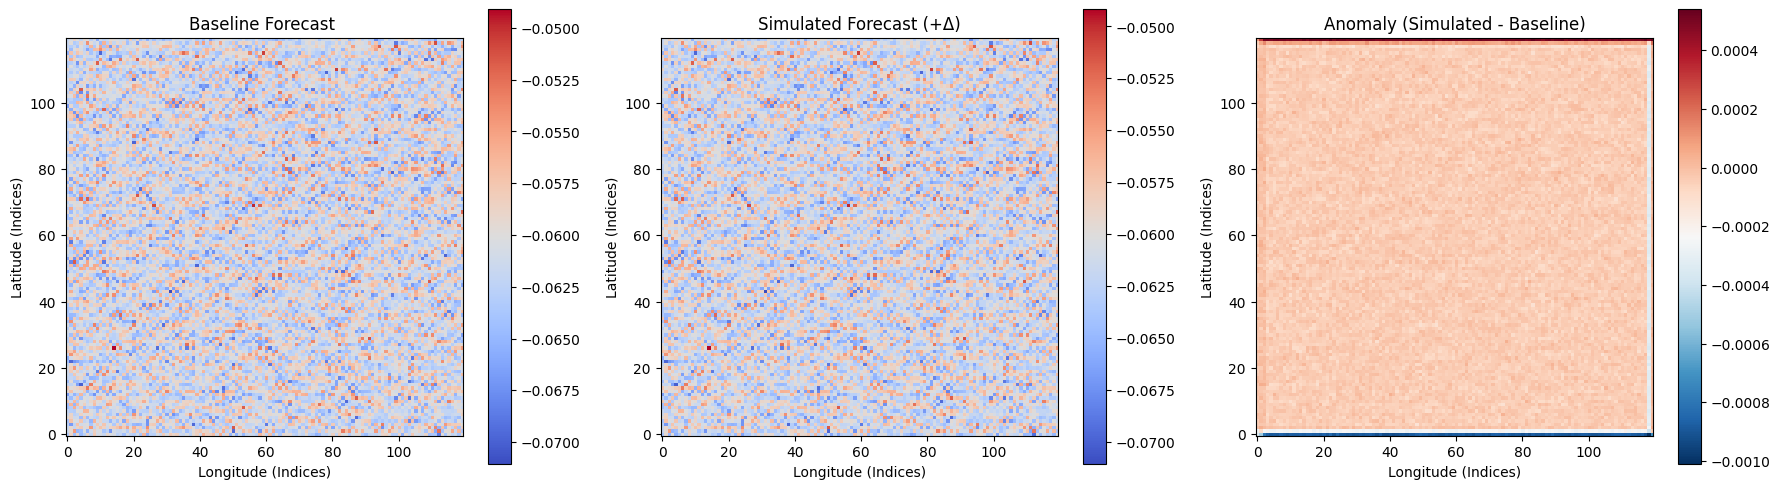

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_climate_impact(baseline, simulated, anomaly, title_suffix=''):
    """
    Visualizes the spatial output of the Digital Twin Engine.
    """
    # Convert tensors to numpy arrays for plotting
    b_np = baseline.squeeze().cpu().numpy()
    s_np = simulated.squeeze().cpu().numpy()
    a_np = anomaly.squeeze().cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot Baseline
    im0 = axes[0].imshow(b_np, cmap='coolwarm', origin='lower')
    axes[0].set_title(f'Baseline Forecast {title_suffix}')
    fig.colorbar(im0, ax=axes[0])

    # Plot Simulated
    im1 = axes[1].imshow(s_np, cmap='coolwarm', origin='lower')
    axes[1].set_title(f'Simulated Forecast (+Δ)')
    fig.colorbar(im1, ax=axes[1])

    # Plot Anomaly (Difference)
    im2 = axes[2].imshow(a_np, cmap='RdBu_r', origin='lower')
    axes[2].set_title('Anomaly (Simulated - Baseline)')
    fig.colorbar(im2, ax=axes[2])

    for ax in axes:
        ax.set_xlabel('Longitude (Indices)')
        ax.set_ylabel('Latitude (Indices)')

    plt.tight_layout()
    plt.show()

# Visualize the results from the previous simulation
visualize_climate_impact(baseline_out, simulated_out, anomaly_map)

In [ ]:
import subprocess

# Clone the RAFT repository
raft_repo_url = "https://github.com/princeton-vl/RAFT.git"
subprocess.run(["git", "clone", raft_repo_url])

print("RAFT repository cloned successfully.")

RAFT repository cloned successfully.
